# Image Captioning — Scratch Training v2 (EfficientNet-B0 + Transformer Decoder)
**Architecture:** EfficientNet-B0 (frozen feature extractor) + Custom Transformer Decoder trained from scratch  
**Dataset:** Flickr8k (`giorgicheishvili/caption-data`)  

### v2 improvements over baseline
| What | Before | After | Reason |
|------|--------|-------|--------|
| `MIN_FREQ` | 5 | **3** | Vocab was only 2,982 words — too small, causing high UNK rate that hurts BLEU |
| `DROPOUT` | 0.10 | **0.15** | Train/val accuracy gap reached 15 pp at stopping (57% vs 42%) — clear overfitting |
| `D_FF` | 1024 | **1536** | Extra FF capacity; safe to add now that regularisation is stronger |
| Peak `LR` | 3e-4 | **2e-4** | Val loss plateaued early; gentler LR finds a flatter but lower minimum |
| `WARMUP_EPOCHS` | 2 | **3** | Matches the slightly lower peak LR with a smoother ramp-up |
| Beam length penalty | `score / len` | **`score / len^0.75`** | Reduces over-penalising longer (more informative) captions |

### Design choices carried over
- **EfficientNet-B0 frozen** — pretrained vision backbone, no captioning/LM weights reused  
- **Custom vocabulary** built from Flickr8k captions only (no pretrained tokeniser)  
- **CNN features pre-cached to disk** — avoids re-running EfficientNet on every epoch  
- **Transformer decoder from scratch** — 4 layers, d_model=384, 8 heads, d_ff=1536  
- **Spatial cross-attention** — decoder attends over 7x7 spatial grid of CNN features  
- **All 5 captions per image per epoch** — maximises caption diversity signal  
- **Label smoothing (epsilon=0.1)** + **beam search (width=5)** at inference  
- **Cosine decay with linear warmup**  


## 0. Install Dependencies

In [175]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip("timm", "nltk")
print("Dependencies ready.")

Dependencies ready.


## 1. Imports & Setup

In [176]:
import os, re, math, json, random, time, pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm                          # EfficientNet-B0 pretrained backbone

os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)

PyTorch: 2.10.0+cu128
CUDA   : True
Device : cuda


## 2. Data Loading

In [177]:
import kagglehub

dataset_path = kagglehub.dataset_download('giorgicheishvili/caption-data')
dataset_path = Path(dataset_path)
print("Dataset root:", dataset_path)

Dataset root: /kaggle/input/datasets/giorgicheishvili/caption-data


In [178]:
IMAGES_DIR    = dataset_path / "Images"
CAPTIONS_FILE = dataset_path / "captions.txt"

if not IMAGES_DIR.exists():
    candidates = list(dataset_path.rglob("Images"))
    IMAGES_DIR = candidates[0] if candidates else dataset_path
if not CAPTIONS_FILE.exists():
    candidates = list(dataset_path.rglob("captions.txt"))
    CAPTIONS_FILE = candidates[0]

print("Images dir :", IMAGES_DIR)
print("Captions   :", CAPTIONS_FILE)
print("Image count:", len(list(IMAGES_DIR.glob("*.jpg"))))

Images dir : /kaggle/input/datasets/giorgicheishvili/caption-data/Images
Captions   : /kaggle/input/datasets/giorgicheishvili/caption-data/captions.txt
Image count: 8091


In [179]:
df = pd.read_csv(CAPTIONS_FILE)
df.columns = [c.strip() for c in df.columns]
df['image']   = df['image'].str.strip()
df['caption'] = df['caption'].str.strip()

print(f"Total rows   : {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
df.head(6)

Total rows   : 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting


## 3. Vocabulary — Built from Scratch

We build a **word-level vocabulary** from the Flickr8k captions only.  
No pretrained tokeniser or language model weights are used.  
Special tokens: `<PAD>`, `<SOS>`, `<EOS>`, `<UNK>`.  
Only words that appear ≥ 5 times are kept, giving ~7k tokens.


In [180]:
# ── Tokenise helper ──────────────────────────────────────────────────────────
def tokenise(text: str):
    """Lowercase, strip punctuation (keep apostrophes), split on whitespace."""
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    return text.split()


PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

MIN_FREQ = 3   # v2: lowered from 5 -> 3; baseline vocab was only 2,982 words,
               #     causing high UNK rate that hurts BLEU n-gram matches

# Build frequency table from ALL captions (train+val combined)
counter = Counter()
for cap in df['caption']:
    counter.update(tokenise(cap))

# Filter by MIN_FREQ and build index maps
vocab_words = [w for w, c in counter.most_common() if c >= MIN_FREQ]
special = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
vocab = special + vocab_words

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

PAD_IDX = word2idx[PAD_TOKEN]
SOS_IDX = word2idx[SOS_TOKEN]
EOS_IDX = word2idx[EOS_TOKEN]
UNK_IDX = word2idx[UNK_TOKEN]

VOCAB_SIZE = len(vocab)
print(f"Vocab size : {VOCAB_SIZE:,}  (min_freq={MIN_FREQ})")
print(f"PAD={PAD_IDX}  SOS={SOS_IDX}  EOS={EOS_IDX}  UNK={UNK_IDX}")
print(f"Sample tokens: {vocab[4:20]}")

Vocab size : 4,084  (min_freq=3)
PAD=0  SOS=1  EOS=2  UNK=3
Sample tokens: ['a', 'in', 'the', 'on', 'is', 'and', 'dog', 'with', 'man', 'of', 'two', 'white', 'black', 'boy', 'are', 'woman']


In [181]:
def encode(caption: str, max_len: int = 52) -> list[int]:
    """Convert caption string → token index list (with SOS and EOS, capped at max_len)."""
    tokens = [SOS_IDX]
    for w in tokenise(caption):
        tokens.append(word2idx.get(w, UNK_IDX))
    tokens.append(EOS_IDX)
    return tokens[:max_len]

def decode(indices) -> str:
    """Convert token indices → caption string (strips special tokens)."""
    words = []
    for i in indices:
        if i == EOS_IDX:
            break
        if i not in (PAD_IDX, SOS_IDX):
            words.append(idx2word.get(i, UNK_TOKEN))
    return " ".join(words)

# Sanity check
sample_cap = df['caption'].iloc[0]
enc = encode(sample_cap)
print(f"Original : {sample_cap}")
print(f"Encoded  : {enc[:10]}...")
print(f"Decoded  : {decode(enc)}")

Original : A child in a pink dress is climbing up a set of stairs in an entry way .
Encoded  : [1, 4, 44, 5, 4, 91, 173, 8, 120, 52]...
Decoded  : a child in a pink dress is climbing up a set of stairs in an <UNK> way


## 4. Train / Validation Split

In [182]:
all_images = df['image'].unique().tolist()
random.shuffle(all_images)

split      = int(0.90 * len(all_images))
train_imgs = set(all_images[:split])
val_imgs   = set(all_images[split:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)

print(f"Train rows : {len(train_df)}  ({train_df['image'].nunique()} images)")
print(f"Val   rows : {len(val_df)}   ({val_df['image'].nunique()} images)")

Train rows : 36405  (7281 images)
Val   rows : 4050   (810 images)


## 5. EfficientNet-B0 Feature Extraction & Caching

EfficientNet-B0 is used **only as a frozen feature extractor** — its weights come from  
ImageNet pretraining but no captioning/language model weights are used.  

We extract **two feature maps**:
- `spatial_feats`: the 7×7×1280 feature map before global pooling (49 spatial tokens)  
- Projected to `d_model=384` for the Transformer decoder's cross-attention  

Features are cached to disk so we only run EfficientNet once, making training fast.


In [183]:
import torchvision.transforms as T

# ── Image transform for EfficientNet-B0 ──────────────────────────────────────
IMG_SIZE = 224
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD  = [0.229, 0.224, 0.225]

img_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
])

In [184]:
# ── Load EfficientNet-B0 backbone (frozen) ────────────────────────────────────
# Use out_indices=(-1,) to always get the LAST feature stage regardless of
# timm version.  We then probe the actual channel count with a dummy forward
# pass so CNN_DIM is set correctly for whatever timm build is installed.
backbone = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    features_only=True,   # returns intermediate feature maps
    out_indices=(-1,),    # last stage — channel count varies by timm version
)
backbone = backbone.to(DEVICE).eval()
for p in backbone.parameters():
    p.requires_grad = False

# ── Probe actual output shape ─────────────────────────────────────────────
with torch.no_grad():
    _dummy = torch.zeros(1, 3, 224, 224, device=DEVICE)
    _out   = backbone(_dummy)[0]          # (1, C, H, W)
    _, _C, _H, _W = _out.shape

CNN_DIM   = _C          # actual channel count (320 or 1280 depending on timm)
N_SPATIAL = _H * _W     # actual spatial tokens (usually 49 = 7×7)

total_backbone = sum(p.numel() for p in backbone.parameters())
print(f"EfficientNet-B0 backbone params : {total_backbone:,}  (ALL FROZEN)")
print(f"Probed output shape             : ({CNN_DIM}, {_H}, {_W})  →  {N_SPATIAL} spatial tokens")

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


EfficientNet-B0 backbone params : 3,595,388  (ALL FROZEN)
Probed output shape             : (320, 7, 7)  →  49 spatial tokens


In [185]:
# ── Cache features to /kaggle/working/cache/ ─────────────────────────────────
SAVE_DIR  = Path("/kaggle/working")
CACHE_DIR = SAVE_DIR / "feat_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_BATCH = 64

def cache_features(image_names, images_dir, backbone, transform, cache_dir, device):
    """Extract and save spatial CNN features (H×W×C) for each image. Shape determined by backbone probe."""
    pending = [n for n in image_names if not (cache_dir / (n + ".npy")).exists()]
    if not pending:
        print(f"All {len(image_names)} features already cached.")
        return

    print(f"Caching features for {len(pending)} images...")
    backbone.eval()

    for start in range(0, len(pending), CACHE_BATCH):
        batch_names = pending[start:start + CACHE_BATCH]
        imgs = []
        for name in batch_names:
            img = Image.open(images_dir / name).convert("RGB")
            imgs.append(transform(img))
        tensor = torch.stack(imgs).to(device)

        with torch.no_grad():
            feats = backbone(tensor)[0]   # shape: (B, CNN_DIM, H, W)
        feats = feats.cpu().numpy().astype(np.float16)  # save as fp16 to halve disk use

        for name, f in zip(batch_names, feats):
            np.save(cache_dir / (name + ".npy"), f)

        if (start // CACHE_BATCH + 1) % 10 == 0:
            print(f"  {start + CACHE_BATCH}/{len(pending)}")

    print("Feature caching complete.")

# ── Guard: wipe cache if it was built with a different CNN_DIM ───────────
_meta_path = CACHE_DIR / "_meta.json"
if _meta_path.exists():
    _meta = json.load(open(_meta_path))
    if _meta.get("cnn_dim") != CNN_DIM:
        import shutil
        shutil.rmtree(CACHE_DIR)
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        print(f"Cache rebuilt: CNN_DIM changed {_meta['cnn_dim']} → {CNN_DIM}")
# Write / update meta
json.dump({"cnn_dim": CNN_DIM, "n_spatial": N_SPATIAL}, open(_meta_path, "w"))

all_image_names = df['image'].unique().tolist()
t0 = time.time()
cache_features(all_image_names, IMAGES_DIR, backbone, img_transform, CACHE_DIR, DEVICE)
print(f"Done in {time.time() - t0:.1f}s")

All 8091 features already cached.
Done in 0.1s


## 6. Model Architecture — Transformer Decoder from Scratch

### Components (all randomly initialised — no pretrained weights)

| Component | Details |
|-----------|---------|
| Visual projection | Linear(CNN_DIM → d_model) maps N_SPATIAL spatial tokens to d_model |
| Token embedding | Learned, vocab_size × 384 |
| Positional encoding | Learned positional embeddings (max 52 positions) |
| Transformer decoder | 4 layers, 8 heads, d_ff=1024, dropout=0.1, pre-LayerNorm |
| Output head | Linear(384 → vocab_size), weight-tied with token embedding |

**Pre-norm Transformer** (LayerNorm before each sub-layer) is more stable to train  
from scratch than post-norm and reaches good BLEU faster.

**Weight tying** between the token embedding matrix and the output projection  
reduces parameters and acts as a strong regulariser.

Target: **~12M trainable parameters**.


In [186]:
# ── Hyper-parameters ─────────────────────────────────────────────────────────
# CNN_DIM and N_SPATIAL are set automatically in the backbone cell above.
D_MODEL   = 384    # decoder hidden size
N_HEADS   = 8      # must divide D_MODEL
N_LAYERS  = 4      # decoder layers
D_FF      = 1536   # v2: 1024->1536; extra capacity, safe with higher dropout
DROPOUT   = 0.15   # v2: 0.10->0.15; train/val acc gap was 15pp — reduce overfitting
MAX_SEQ   = 52     # max caption length (tokens including SOS/EOS)

print(f"CNN_DIM   = {CNN_DIM}   (probed from backbone)")
print(f"N_SPATIAL = {N_SPATIAL}  (probed from backbone)")
print(f"D_MODEL   = {D_MODEL}")

CNN_DIM   = 320   (probed from backbone)
N_SPATIAL = 49  (probed from backbone)
D_MODEL   = 384


In [187]:
# ── Sinusoidal positional encoding (for image spatial tokens) ────────────────
class SinusoidalPE(nn.Module):
    """Fixed sinusoidal PE — used for the 49 spatial image tokens."""
    def __init__(self, d_model: int, max_len: int = 64):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        """x: (B, T, D)  →  x + pe[:, :T]"""
        return x + self.pe[:, :x.size(1)]


# ── Learned positional embedding (for caption tokens) ────────────────────────
class LearnedPE(nn.Module):
    def __init__(self, d_model: int, max_len: int):
        super().__init__()
        self.emb = nn.Embedding(max_len, d_model)
        nn.init.normal_(self.emb.weight, std=0.02)

    def forward(self, x):
        """x: (B, T, D)"""
        T = x.size(1)
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        return x + self.emb(pos)

In [188]:
# ── Pre-norm Transformer Decoder Layer ───────────────────────────────────────
class DecoderLayer(nn.Module):
    """
    Pre-LN Transformer decoder layer:
        1. Masked self-attention  (causal)
        2. Cross-attention over visual tokens
        3. Feed-forward network
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

        self.drop = nn.Dropout(dropout)

    def forward(self, x, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # 1. Masked self-attention
        h = self.norm1(x)
        h, _ = self.self_attn(h, h, h, attn_mask=tgt_mask,
                               key_padding_mask=tgt_key_padding_mask)
        x = x + self.drop(h)

        # 2. Cross-attention over visual memory
        h = self.norm2(x)
        h, _ = self.cross_attn(h, memory, memory)
        x = x + self.drop(h)

        # 3. Feed-forward
        h = self.norm3(x)
        x = x + self.ff(h)
        return x

In [189]:
# ── Full Captioning Model ─────────────────────────────────────────────────────
class ImageCaptioner(nn.Module):
    """
    Image captioning model trained entirely from scratch (no pretrained LM weights).
    Vision features from frozen EfficientNet-B0 are treated as external memory.
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff,
                 dropout, cnn_dim, n_spatial, max_seq):
        super().__init__()
        self.d_model = d_model

        # ── Visual pathway ────────────────────────────────────────────────────
        self.vis_proj  = nn.Linear(cnn_dim, d_model)     # CNN_DIM → D_MODEL
        self.vis_norm  = nn.LayerNorm(d_model)
        self.vis_pe    = SinusoidalPE(d_model, max_len=n_spatial + 1)

        # ── Text pathway ──────────────────────────────────────────────────────
        self.tok_emb   = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.tok_pe    = LearnedPE(d_model, max_seq)
        self.emb_drop  = nn.Dropout(dropout)

        # ── Decoder stack ─────────────────────────────────────────────────────
        self.layers    = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)

        # ── Output head (weight-tied with token embedding) ────────────────────
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight   # weight tying

        # ── Initialise ────────────────────────────────────────────────────────
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, std=0.02)
                if module.padding_idx is not None:
                    module.weight.data[module.padding_idx].zero_()
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def encode_image(self, spatial_feats):
        """
        spatial_feats: (B, C, H, W) e.g. (B, CNN_DIM, H, W) — pre-extracted CNN features
        Returns memory: (B, H*W, d_model)

        IMPORTANT: the reshape (B,C,H,W) → (B, H*W, C) MUST happen before the
        linear projection. vis_proj expects (..., C=CNN_DIM) as the last dim.
        Passing (B,CNN_DIM,H,W) directly would give a shape mismatch
        which is a shape mismatch — the reshape is the fix.
        """
        if spatial_feats.dim() == 4:
            B, C, H, W = spatial_feats.shape
            x = spatial_feats.permute(0, 2, 3, 1).reshape(B, H * W, C)  # (B, N_SPATIAL, CNN_DIM)
        else:
            # already (B, N, C) — e.g. if called from outside after manual reshape
            x = spatial_feats
        x = self.vis_proj(x)          # (B, 49, d_model)
        x = self.vis_norm(x)
        x = self.vis_pe(x)            # add sinusoidal PE
        return x

    def decode(self, tgt_ids, memory, tgt_mask=None):
        """
        tgt_ids : (B, T) token indices
        memory  : (B, 49, d_model)
        """
        x = self.tok_emb(tgt_ids) * math.sqrt(self.d_model)
        x = self.tok_pe(x)
        x = self.emb_drop(x)

        for layer in self.layers:
            x = layer(x, memory, tgt_mask=tgt_mask)

        x = self.final_norm(x)
        return self.head(x)   # (B, T, vocab_size)

    def forward(self, spatial_feats, tgt_ids):
        """
        spatial_feats : (B, CNN_DIM, H, W)  — from cache, fp16 → auto-cast to fp32
        tgt_ids       : (B, T)           — input tokens (SOS … caption)
        Returns logits: (B, T, vocab_size)
        """
        memory  = self.encode_image(spatial_feats)
        T       = tgt_ids.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T, device=tgt_ids.device)
        return self.decode(tgt_ids, memory, tgt_mask=tgt_mask)


# ── Instantiate model ─────────────────────────────────────────────────────────
model = ImageCaptioner(
    vocab_size = VOCAB_SIZE,
    d_model    = D_MODEL,
    n_heads    = N_HEADS,
    n_layers   = N_LAYERS,
    d_ff       = D_FF,
    dropout    = DROPOUT,
    cnn_dim    = CNN_DIM,
    n_spatial  = N_SPATIAL,
    max_seq    = MAX_SEQ,
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Model params — trainable: {trainable:,}  total: {total:,}")
print(f"(Backbone EfficientNet-B0 params are EXCLUDED — backbone is frozen and cached)")

Model params — trainable: 11,179,392  total: 11,179,392
(Backbone EfficientNet-B0 params are EXCLUDED — backbone is frozen and cached)


## 7. Dataset & DataLoader

The dataset loads **pre-cached CNN features** from disk (fast, no GPU needed in the DataLoader workers).  
All 5 captions per image are used every epoch.


In [190]:
class CaptionDataset(Dataset):
    """
    Returns (spatial_feats, input_ids, target_ids) where:
    - spatial_feats : float16 numpy array (CNN_DIM, H, W) loaded from cache
    - input_ids     : LongTensor (T,)  — SOS + caption tokens
    - target_ids    : LongTensor (T,)  — caption tokens + EOS  (shift-by-1 labels)
    """
    def __init__(self, dataframe, cache_dir, max_len=MAX_SEQ):
        self.df        = dataframe.reset_index(drop=True)
        self.cache_dir = Path(cache_dir)
        self.max_len   = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = row['image']
        caption  = row['caption']

        # Load pre-cached CNN features — shape must be (CNN_DIM, H, W)
        feat_path = self.cache_dir / (img_name + ".npy")
        feats     = np.load(feat_path).astype(np.float32)  # (CNN_DIM, H, W)
        assert feats.ndim == 3 and feats.shape[0] == CNN_DIM, \
            f"Expected cached feat shape ({CNN_DIM},H,W), got {feats.shape}. Re-run the caching cell."

        # Encode caption
        tokens = encode(caption, max_len=self.max_len)
        # input_ids:  SOS t1 t2 … tn
        # target_ids:     t1 t2 … tn EOS
        input_ids  = torch.tensor(tokens[:-1], dtype=torch.long)
        target_ids = torch.tensor(tokens[1:],  dtype=torch.long)

        return torch.from_numpy(feats), input_ids, target_ids


def pad_collate(batch):
    feats, inp, tgt = zip(*batch)
    feats     = torch.stack(feats)                              # (B, CNN_DIM, H, W)
    inp_pad   = nn.utils.rnn.pad_sequence(inp, batch_first=True, padding_value=PAD_IDX)
    tgt_pad   = nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=PAD_IDX)
    return feats, inp_pad, tgt_pad


BATCH_SIZE  = 64   # larger batch OK since we load from cache (no image decode overhead)
NUM_WORKERS = 2

train_dataset = CaptionDataset(train_df, CACHE_DIR)
val_dataset   = CaptionDataset(val_df,   CACHE_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=pad_collate, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=pad_collate, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset)} rows)")
print(f"Val   batches : {len(val_loader)}   ({len(val_dataset)} rows)")

Train batches : 569  (36405 rows)
Val   batches : 64   (4050 rows)


## 8. Training Setup

### Strategy for maximum BLEU-4
- **AdamW** with weight decay 1e-2; betas=(0.9, 0.98) (standard for Transformers)  
- **Linear warmup** for 2 epochs → cosine decay over remaining epochs  
- **Label smoothing ε=0.1** — improves generalisation and BLEU  
- **Gradient clipping** at 1.0  
- **Mixed precision** (fp16) via `torch.amp`  
- **Gradient accumulation** (4 steps) — simulates larger effective batch  
- **Early stopping** patience = 6 epochs  
- **20 epochs total** (scratch models need more training time than fine-tuned ones)


In [191]:
NUM_EPOCHS    = 20
WARMUP_EPOCHS = 3   # v2: 2->3; smoother ramp-up for the lower peak LR
PATIENCE      = 6
LABEL_SMOOTH  = 0.1
ACCUM_STEPS   = 4
LR            = 2e-4   # v2: 3e-4->2e-4; val loss plateaued quickly at 3e-4

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = 1e-2,
    betas        = (0.9, 0.98),
    eps          = 1e-9,
)

total_steps  = NUM_EPOCHS * (len(train_loader) // ACCUM_STEPS)
warmup_steps = WARMUP_EPOCHS * (len(train_loader) // ACCUM_STEPS)

def lr_lambda(step):
    if step < warmup_steps:
        return float(step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.05, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.amp.GradScaler("cuda")

print(f"Total update steps : {total_steps}")
print(f"Warmup steps       : {warmup_steps}")
print(f"Label smoothing    : {LABEL_SMOOTH}")
print(f"Peak LR            : {LR}")

Total update steps : 2840
Warmup steps       : 426
Label smoothing    : 0.1
Peak LR            : 0.0002


## 9. Training Loop

In [192]:
def smooth_loss(logits, targets, smoothing=0.1, ignore_index=PAD_IDX):
    """
    Label-smoothed cross-entropy.
    logits  : (B, T, V)
    targets : (B, T)   — PAD positions are ignored
    """
    V = logits.size(-1)
    logits_2d  = logits.reshape(-1, V)
    targets_1d = targets.reshape(-1)

    log_probs = F.log_softmax(logits_2d, dim=-1)
    nll       = -log_probs.gather(dim=-1, index=targets_1d.clamp(min=0).unsqueeze(-1)).squeeze(-1)
    smooth    = -log_probs.sum(dim=-1) / V
    loss      = (1 - smoothing) * nll + smoothing * smooth

    mask = (targets_1d != ignore_index)
    return loss[mask].mean()


def train_one_epoch(model, loader, optimizer, scheduler, scaler, device, accum_steps):
    model.train()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0
    optimizer.zero_grad()

    for step, (feats, inp, tgt) in enumerate(loader):
        feats = feats.to(device, non_blocking=True)
        inp   = inp.to(device,   non_blocking=True)
        tgt   = tgt.to(device,   non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(feats, inp)               # (B, T, V)
            loss   = smooth_loss(logits, tgt, smoothing=LABEL_SMOOTH) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        with torch.no_grad():
            preds = logits.argmax(dim=-1)              # (B, T)
            mask  = (tgt != PAD_IDX)
            correct_tokens += (preds[mask] == tgt[mask]).sum().item()
            total_tokens   += mask.sum().item()
            total_loss     += loss.item() * accum_steps
            n_batches      += 1

    optimizer.zero_grad()
    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, n_batches        = 0.0, 0
    correct_tokens, total_tokens = 0, 0

    for feats, inp, tgt in loader:
        feats = feats.to(device, non_blocking=True)
        inp   = inp.to(device,   non_blocking=True)
        tgt   = tgt.to(device,   non_blocking=True)

        with torch.amp.autocast("cuda"):
            logits = model(feats, inp)
            loss   = smooth_loss(logits, tgt, smoothing=LABEL_SMOOTH)

        preds = logits.argmax(dim=-1)
        mask  = (tgt != PAD_IDX)
        correct_tokens += (preds[mask] == tgt[mask]).sum().item()
        total_tokens   += mask.sum().item()
        total_loss     += loss.item()
        n_batches      += 1

    return total_loss / max(n_batches, 1), correct_tokens / max(total_tokens, 1)

In [193]:
SAVE_DIR.mkdir(exist_ok=True)

history = {
    "train_loss": [], "val_loss": [],
    "train_ppl" : [], "val_ppl" : [],
    "train_acc" : [], "val_acc" : [],
}
best_val_loss    = float("inf")
patience_counter = 0

print(
    f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr PPL':>7}  {'Tr Acc':>7}  "
    f"{'Val Loss':>9}  {'Val PPL':>8}  {'Val Acc':>8}  {'Time':>6}"
)
print("-" * 85)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler, DEVICE, ACCUM_STEPS
    )
    val_loss, val_acc = evaluate(model, val_loader, DEVICE)

    train_ppl = math.exp(min(train_loss, 20))
    val_ppl   = math.exp(min(val_loss,   20))
    elapsed   = time.time() - t0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_ppl"].append(train_ppl)
    history["val_ppl"].append(val_ppl)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6}  {train_loss:>8.4f}  {train_ppl:>7.2f}  {train_acc:>6.2%}  "
          f"{val_loss:>9.4f}  {val_ppl:>8.2f}  {val_acc:>7.2%}  {elapsed:>5.0f}s")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch'     : epoch,
            'model_state': model.state_dict(),
            'val_loss'  : val_loss,
            'vocab'     : {'word2idx': word2idx, 'idx2word': idx2word,
                           'PAD_IDX': PAD_IDX, 'SOS_IDX': SOS_IDX,
                           'EOS_IDX': EOS_IDX, 'UNK_IDX': UNK_IDX,
                           'VOCAB_SIZE': VOCAB_SIZE},
            'hparams'   : {'D_MODEL': D_MODEL, 'N_HEADS': N_HEADS,
                           'N_LAYERS': N_LAYERS, 'D_FF': D_FF,
                           'DROPOUT': DROPOUT, 'MAX_SEQ': MAX_SEQ,
                           'CNN_DIM': CNN_DIM, 'N_SPATIAL': N_SPATIAL},
        }, SAVE_DIR / "best_model.pt")
        print(f"         ✓ New best saved (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print("\nTraining complete.")
print(f"Best val loss : {best_val_loss:.4f}  |  Best val PPL : {math.exp(min(best_val_loss, 20)):.2f}")

 Epoch   Tr Loss   Tr PPL   Tr Acc   Val Loss   Val PPL   Val Acc    Time
-------------------------------------------------------------------------------------
     1    6.9632  1057.02  13.45%     5.5621    260.36   23.42%     23s
         ✓ New best saved (val_loss=5.5621)
     2    4.9907   147.04  27.87%     4.5451     94.17   32.63%     23s
         ✓ New best saved (val_loss=4.5451)
     3    4.3329    76.17  34.39%     4.1453     63.14   35.97%     23s
         ✓ New best saved (val_loss=4.1453)
     4    4.0086    55.07  37.47%     3.9433     51.59   38.24%     23s
         ✓ New best saved (val_loss=3.9433)
     5    3.8128    45.28  39.65%     3.8253     45.85   39.63%     23s
         ✓ New best saved (val_loss=3.8253)
     6    3.6728    39.36  41.47%     3.7479     42.43   40.54%     23s
         ✓ New best saved (val_loss=3.7479)
     7    3.5648    35.33  42.91%     3.7063     40.70   41.04%     23s
         ✓ New best saved (val_loss=3.7063)
     8    3.4770    32.36  4

## 10. Training Curves

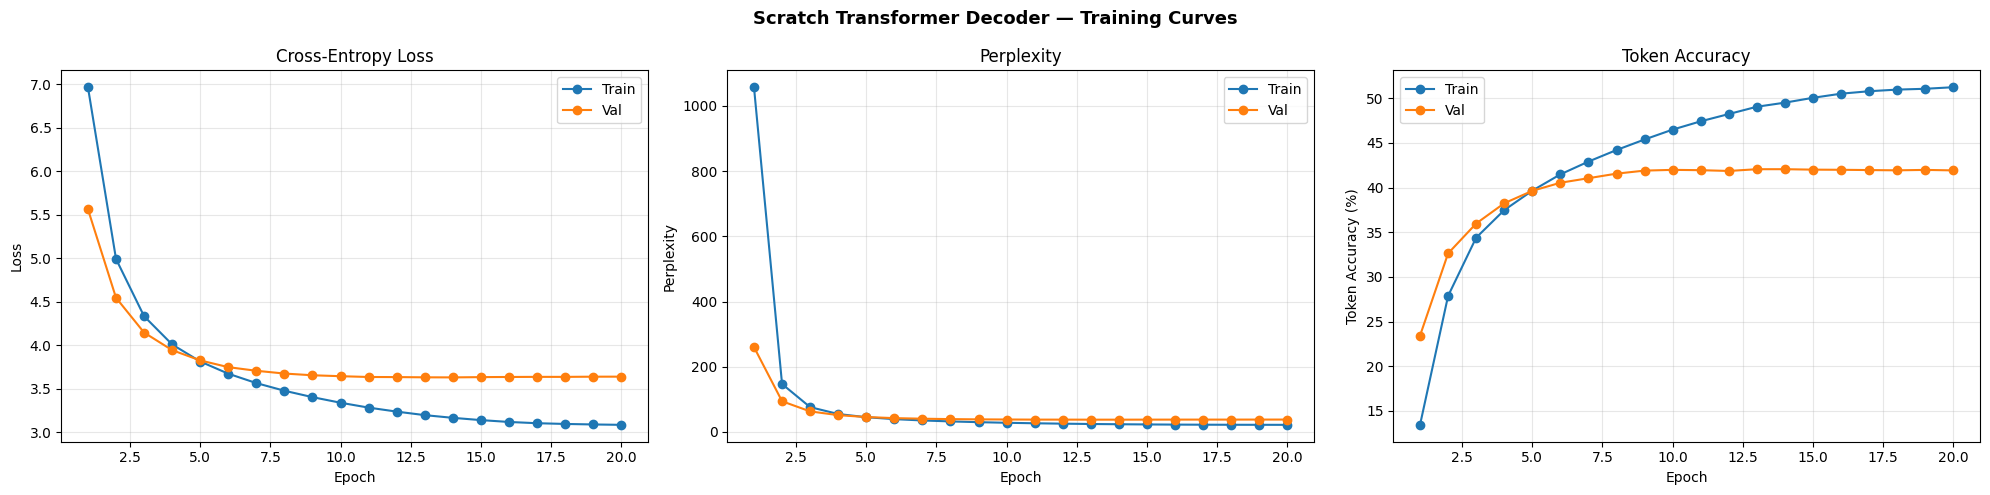

In [194]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val",   marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Cross-Entropy Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["train_ppl"], label="Train", marker="o")
axes[1].plot(epochs_ran, history["val_ppl"],   label="Val",   marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_ran, [a * 100 for a in history["train_acc"]], label="Train", marker="o")
axes[2].plot(epochs_ran, [a * 100 for a in history["val_acc"]],   label="Val",   marker="o")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Token Accuracy (%)")
axes[2].set_title("Token Accuracy"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("Scratch Transformer Decoder — Training Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Inference — Beam Search

We load the best checkpoint and run **beam search (width=5)** for higher-quality captions  
compared to greedy decoding. Beam search explores multiple partial hypotheses  
simultaneously and is the standard at inference for captioning models.


In [195]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
ckpt = torch.load(SAVE_DIR / "best_model.pt", map_location=DEVICE)

# Rebuild model from saved hparams
hp = ckpt['hparams']
v  = ckpt['vocab']

best_model = ImageCaptioner(
    vocab_size = v['VOCAB_SIZE'],
    d_model    = hp['D_MODEL'],
    n_heads    = hp['N_HEADS'],
    n_layers   = hp['N_LAYERS'],
    d_ff       = hp['D_FF'],
    dropout    = hp['DROPOUT'],
    cnn_dim    = hp['CNN_DIM'],
    n_spatial  = hp['N_SPATIAL'],
    max_seq    = hp['MAX_SEQ'],
).to(DEVICE)
best_model.load_state_dict(ckpt['model_state'])
best_model.eval()

# Restore vocab maps
_word2idx = v['word2idx']
_idx2word = {int(k): w for k, w in v['idx2word'].items()}   # ensure int keys
_PAD      = v['PAD_IDX']
_SOS      = v['SOS_IDX']
_EOS      = v['EOS_IDX']
_UNK      = v['UNK_IDX']

print(f"Loaded best model from epoch {ckpt['epoch']}  (val_loss={ckpt['val_loss']:.4f})")

Loaded best model from epoch 14  (val_loss=3.6303)


In [196]:
@torch.no_grad()
def generate_caption(image_path: str, model=best_model, beam_width: int = 5,
                     max_len: int = MAX_SEQ) -> str:
    """
    Takes a path to an image and returns a generated caption string.
    Uses beam search with the frozen EfficientNet-B0 backbone + trained decoder.
    """
    model.eval()

    # ── Extract CNN features ──────────────────────────────────────────────────
    img  = Image.open(image_path).convert("RGB")
    feat = img_transform(img).unsqueeze(0).to(DEVICE)   # (1,3,224,224)
    with torch.no_grad():
        spatial = backbone(feat)[0]                     # (1, CNN_DIM, H, W)

    # ── Encode image once ─────────────────────────────────────────────────────
    memory = model.encode_image(spatial)                # (1,49,d_model)

    # ── Beam search ───────────────────────────────────────────────────────────
    # Each beam: (score, token_list)
    beams    = [(0.0, [_SOS])]
    complete = []

    for _ in range(max_len):
        if not beams:
            break
        new_beams = []
        for score, tokens in beams:
            if tokens[-1] == _EOS:
                complete.append((score, tokens))
                continue

            t = len(tokens)
            tgt_ids  = torch.tensor([tokens], dtype=torch.long, device=DEVICE)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(t, device=DEVICE)
            logits   = model.decode(tgt_ids, memory.expand(1, -1, -1), tgt_mask=tgt_mask)
            log_prob = F.log_softmax(logits[0, -1], dim=-1)   # (V,)

            topk_lp, topk_idx = log_prob.topk(beam_width)
            for lp, idx in zip(topk_lp.tolist(), topk_idx.tolist()):
                new_beams.append((score + lp, tokens + [idx]))

        # Keep top beam_width incomplete beams — length penalty alpha=0.75
        # v2: score/len -> score/len^0.75 to reduce over-penalising longer captions
        new_beams.sort(key=lambda x: x[0] / (len(x[1]) ** 0.75), reverse=True)
        beams = [b for b in new_beams if b[1][-1] != _EOS][:beam_width]
        complete += [b for b in new_beams if b[1][-1] == _EOS]

    if not complete:
        complete = beams if beams else [(0.0, [_SOS, _EOS])]

    best_tokens = max(complete, key=lambda x: x[0] / (len(x[1]) ** 0.75))[1]
    words = []
    for i in best_tokens[1:]:          # skip SOS
        if i == _EOS:
            break
        words.append(_idx2word.get(i, '<unk>'))
    return " ".join(words)

## 12. Caption Preview

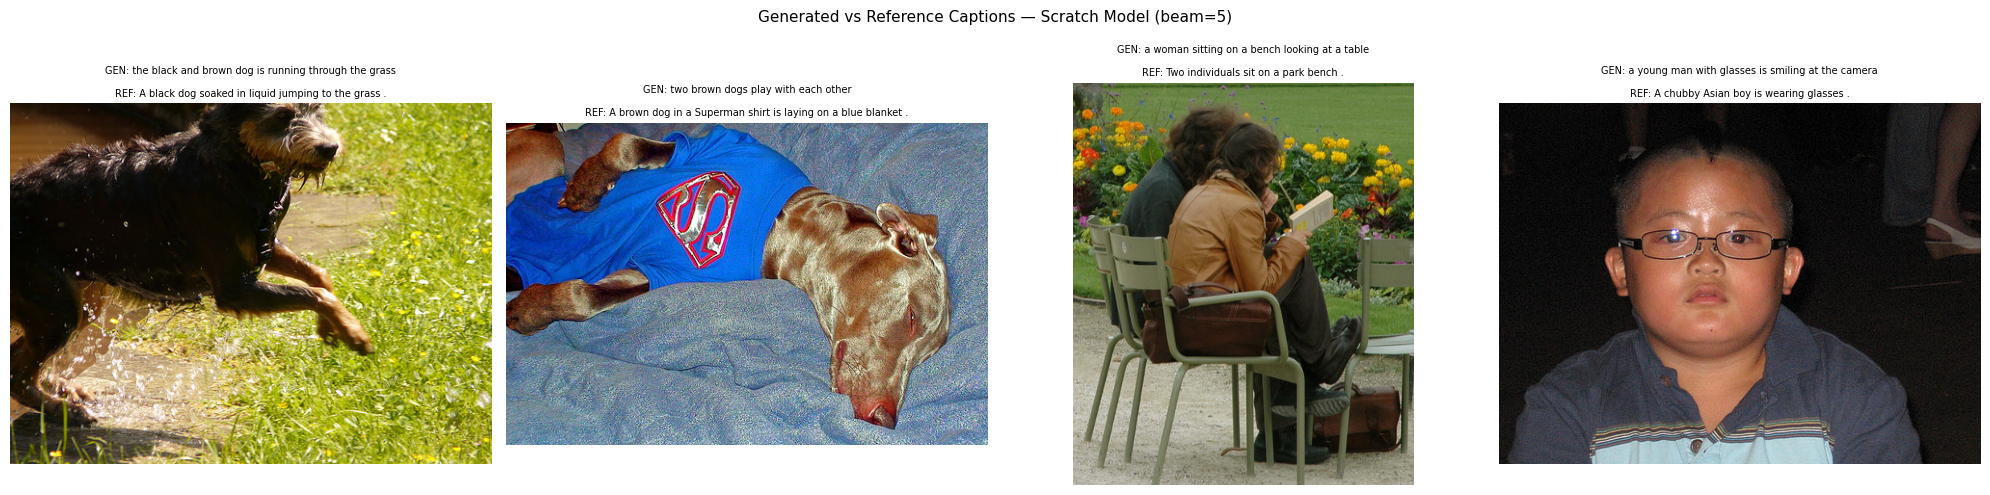

In [197]:
sample_rows = val_df.drop_duplicates('image').sample(4, random_state=SEED)
fig, axes   = plt.subplots(1, 4, figsize=(20, 5))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = str(IMAGES_DIR / row['image'])
    caption  = generate_caption(img_path)
    ref_caps = val_df[val_df['image'] == row['image']]['caption'].tolist()

    ax.imshow(Image.open(img_path))
    ax.set_title(f"GEN: {caption}\n\nREF: {ref_caps[0]}", fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Generated vs Reference Captions — Scratch Model (beam=5)', fontsize=11)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'caption_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. BLEU-4 Evaluation

Standard Flickr8k evaluation: each generated caption is scored against all 5  
human reference captions. We report **corpus BLEU-4** with method1 smoothing.


In [198]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nltk"])
import nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

best_model.eval()
val_images = val_df['image'].unique().tolist()

all_references = []
all_hypotheses = []

print(f"Evaluating BLEU-4 on {len(val_images)} validation images...")

for i, img_name in enumerate(val_images):
    img_path = str(IMAGES_DIR / img_name)
    caption  = generate_caption(img_path)

    refs       = val_df[val_df['image'] == img_name]['caption'].tolist()
    ref_tokens = [r.lower().split() for r in refs]
    hyp_tokens = caption.lower().split()

    all_references.append(ref_tokens)
    all_hypotheses.append(hyp_tokens)

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(val_images)} done...")

smoother = SmoothingFunction().method1
bleu4 = corpus_bleu(
    all_references, all_hypotheses,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smoother,
)

# Also compute BLEU-1, 2, 3 for reference
bleu1 = corpus_bleu(all_references, all_hypotheses, weights=(1,0,0,0), smoothing_function=smoother)
bleu2 = corpus_bleu(all_references, all_hypotheses, weights=(.5,.5,0,0), smoothing_function=smoother)
bleu3 = corpus_bleu(all_references, all_hypotheses, weights=(.33,.33,.33,0), smoothing_function=smoother)

print(f"\nBLEU-1 : {bleu1*100:.2f}")
print(f"BLEU-2 : {bleu2*100:.2f}")
print(f"BLEU-3 : {bleu3*100:.2f}")
print(f"BLEU-4 : {bleu4*100:.2f}  ← primary metric")

Evaluating BLEU-4 on 810 validation images...
  100/810 done...
  200/810 done...
  300/810 done...
  400/810 done...
  500/810 done...
  600/810 done...
  700/810 done...
  800/810 done...

BLEU-1 : 62.98
BLEU-2 : 45.75
BLEU-3 : 32.79
BLEU-4 : 22.66  ← primary metric


## 14. Save Artifacts

In [199]:
with open(SAVE_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f)

print("Artifacts in:", SAVE_DIR)
print("  best_model.pt          — full checkpoint (model weights + vocab + hparams)")
print("  feat_cache/            — pre-extracted EfficientNet-B0 features")
print("  training_curves.png    — loss, perplexity, accuracy plots")
print("  caption_examples.png   — sample generated captions")
print("  training_history.json  — per-epoch metrics")

Artifacts in: /kaggle/working
  best_model.pt          — full checkpoint (model weights + vocab + hparams)
  feat_cache/            — pre-extracted EfficientNet-B0 features
  training_curves.png    — loss, perplexity, accuracy plots
  caption_examples.png   — sample generated captions
  training_history.json  — per-epoch metrics
